In [1]:
import time
import os
import gc
import math
import cv2
import numpy as np
import pandas as pd
import pyautogui as pa
import shutil
import re  # regex
from PIL import Image, ImageDraw
import random
from scipy.stats import sem, ttest_ind, norm, ttest_ind_from_stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import imageio
from sklearn.cluster import KMeans

from lib.analysis.trace_metrics import TraceMetrics
from lib.analysis.false_discovery_control import false_discovery_control
from lib.auto_GUI.auto_PhotoZ import AutoPhotoZ
from lib.analysis.laminar_dist import *
from lib.analysis.align import ImageAlign
from lib.file.ROI_writer import ROIFileWriter
from lib.analysis.barrel_roi import Barrel_ROI_Creator
from lib.analysis.cell_roi import RandomROISample, OverlapCounterROI
from lib.analysis.baseline_correction import BaselineCorrection

# 2-way ANOVA for medial and lateral PPR vs IPI
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm

from lib.utilities import *
from lib.file.TIF import *

from ZDA_Adventure.utility import ROIFileReader

import networkx as nx
from skimage.measure import label, regionprops
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import hashlib

try:
    from PPR_PV_anna_Dec2025_progress import rec_id_skip_list
except ImportError:
    rec_id_skip_list = []


In [2]:
rec_id_skip_list

[]

In [3]:
# Load data, not from Drive for Desktop since PhotoZ complains about loading zda from Drive
data_dir = "C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_PVCre/"
camera_program = 4
which_rig = 'old'  # change to 'old' for old rig dic alignment
date_format = 'yy-mm-dd'
if which_rig == 'old':
    date_format = 'yyyy-mm-dd'

# annotation settings
skip_draw_annotations = False  # If True, don't draw any new annotations
disable_annotations = True  # If True, don't draw any annotations

rois_files_to_choose = ['L23', 'L4', "L5"] # choose a set of rois for each of these layer labels
roi_selector_size = 4 # number of pixels to select at a time when choosing rois

exclude_distant_neighbors = True  # whether to exclude distant neighbors from analysis

In [ ]:
# load trace files from the following directory
#data_dir = '/home/john/Desktop/'

#export_csv = data_dir + 'export_summary_anna_rois_only_ppr.csv'
data_dir = 'C:/Users/jjudge3/Desktop/Data/PV-PPR/'
suffix = 'no_spatial_filter'  # _prestim
export_csv = data_dir + f'export_summary_anna_ppr_single_px_lat_map_{suffix}.csv'

camera_program = 4
um_per_px = 6.875 #um
output_fig_dir = 'P:/John/pv-ppr-paper/input/' + suffix + "/"

if not os.path.exists(output_fig_dir):
    os.makedirs(output_fig_dir)

# load the CSVs
ppr_df = pd.read_csv(export_csv)

# add column for Coronal/Sagittal
ppr_df['Section'] = 'Coronal'

ppr_df.shape

36342944

In [ ]:
ppr_df.shape

In [5]:
# load PPR catalog
ppr_catalog = data_dir + "ppr_catalog.csv"
ppr_catalog_df = pd.read_csv(ppr_catalog)

# only keep zda_file, IPI, and Stim_Layer columns
ppr_catalog_df = ppr_catalog_df[['zda_file', 'IPI', 'Stim_Layer', 'Sex', 'Age']]

# parse slice, location, and recording numbers from zda_file and store in new columns
ppr_catalog_df['zda_id'] = ppr_catalog_df['zda_file'].apply(lambda x: x.split('/')[-1].split('.')[0])
ppr_catalog_df['Slice'] = ppr_catalog_df['zda_id'].apply(lambda x: int(x.split('_')[0]))
ppr_catalog_df['Location'] = ppr_catalog_df['zda_id'].apply(lambda x: int(x.split('_')[1]))
ppr_catalog_df['Recording'] = ppr_catalog_df['zda_id'].apply(lambda x: int(x.split('_')[2]))

# parse date from zda_file column. It is in format "/mm-dd-yy/", use pattern matching to extract date (regex)
# Function to extract date using regex
def extract_date(filename):
    match = re.search(r'(\d{2}-\d{2}-\d{2})', filename)
    if match:
        # remove zero padding from day and month
        m,d,y = match.group(0).split('-')
        d = str(int(d))
        m = str(int(m))
        return f"{m}-{d}-{int(y)}"
    return None

ppr_catalog_df['Date'] = ppr_catalog_df['zda_file'].apply(extract_date)
ppr_catalog_df

,zda_file,IPI,Stim_Layer,Sex,Age,zda_id,Slice,Location,Recording,Date
0,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,20,L4,M,69,01_01_01,1,1,1,22-9-2
1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,50,L4,M,69,01_01_02,1,1,2,22-9-2
2,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,100,L4,M,69,01_01_03,1,1,3,22-9-2
3,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,100,L2/3,M,69,01_02_01,1,2,1,22-9-2
4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,20,L2/3,M,69,01_02_02,1,2,2,22-9-2
...,...,...,...,...,...,...,...,...,...,...
1481,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,50,L5,F,72,07_02_04,7,2,4,23-9-17
1482,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,50,L2/3,F,72,07_03_01,7,3,1,23-9-17
1483,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,100,L2/3,F,72,07_03_02,7,3,2,23-9-17
1484,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,200,L2/3,F,72,07_03_03,7,3,3,23-9-17


In [6]:
def read_array_file(filename): 
    data_arr = pd.read_csv(filename,
                                 sep='\t',
                                 header=None,
                                 names=['Index',  'Values'])
    return np.array(data_arr['Values']).reshape((80, 80))

def read_dat_trace_file(filename):
    data_arr = pd.read_csv(filename,
                                 sep='\t',
                                 header=0)  # change me to traces?
    data_arr = data_arr.apply(pd.to_numeric, errors='coerce')
    return data_arr

# for each Date, Slice, Location, Recording in ppr_df, find matching row in ppr_catalog_df and add IPI to ppr_df
ppr_df['IPI'] = np.nan
for index, row in ppr_df.iterrows():
    date = row['Date']
    slice_num = row['Slice']
    location = row['Location']
    recording = row['Recording']
    
    matching_row = ppr_catalog_df[(ppr_catalog_df['Date'] == date) &
                                  (ppr_catalog_df['Slice'] == slice_num) &
                                  (ppr_catalog_df['Location'] == location) &
                                  (ppr_catalog_df['Recording'] == recording)]
    
    if not matching_row.empty:
        ppr_df.at[index, 'IPI'] = matching_row['IPI'].values[0]
        ppr_df.at[index, 'Stim_Layer'] = matching_row['Stim_Layer'].values[0]
        ppr_df.at[index, 'Sex'] = matching_row['Sex'].values[0]
        ppr_df.at[index, 'Age'] = matching_row['Age'].values[0]


ppr_df

,ROI,amp,latency,stim_time,halfwidth,X_Center,Y_Center,ROI_Set,Date,Slice,Location,Recording,trace,amp_array,latency_array,Section,IPI,Stim_Layer,Sex,Age
0,1,0.006193,49.016961,49.250116,5.963251,50,24,analysis02_01_01\rois_layer_L23_output__rand_0...,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0
1,2,0.003313,58.313992,49.250116,2.521589,47,25,analysis02_01_01\rois_layer_L23_output__rand_0...,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0
2,3,0.004972,48.341422,49.250116,20.826213,53,26,analysis02_01_01\rois_layer_L23_output__rand_0...,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0
3,4,0.004545,49.700453,49.250116,3.629035,48,26,analysis02_01_01\rois_layer_L23_output__rand_0...,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0
4,5,0.004687,50.876149,49.250116,12.510404,51,28,analysis02_01_01\rois_layer_L23_output__rand_0...,22-9-2,2,1,1,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2271429,96,0.002100,75.121655,69.250182,19.181481,63,9,analysis07_03_04\rois_layer_L5_output__rand_2 ...,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0
2271430,97,0.001462,69.788103,69.250182,27.923355,55,17,analysis07_03_04\rois_layer_L5_output__rand_2 ...,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0
2271431,98,0.001726,76.404526,69.250182,2.920433,60,22,analysis07_03_04\rois_layer_L5_output__rand_2 ...,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0
2271432,99,0.002552,63.000000,69.250182,24.207214,68,17,analysis07_03_04\rois_layer_L5_output__rand_2 ...,23-9-17,7,3,4,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0


In [7]:

# label pulse number based on "pulse1" and "pulse2" substring in the "ROI_Set" column
def label_pulse(roi_set):
    if 'pulse1' in roi_set:
        return 1
    elif 'pulse2' in roi_set:
        return 2
    else:
        return None
ppr_df['Pulse_Number'] = ppr_df['ROI_Set'].apply(label_pulse)

# subtract stim_time from latency
ppr_df['latency'] = ppr_df['latency'] - ppr_df['stim_time']

# create a column "ROI label" that extracts the ROI label (the first part before " ") from the "ROI_Set" column
ppr_df['ROI_Label'] = ppr_df['ROI_Set'].apply(lambda x: x.split(' ')[0])

# column called "ROI_Loc" that extracts the ROI location (the part after the last "rois_layer_" in the "ROI_Set" column)
ppr_df['ROI_Loc'] = ppr_df['ROI_Set'].apply(lambda x: x.split('rois_layer_')[-1])

# column called "ROI_Loc" that extracts the ROI location (the part after the last "rois_layer_" in the "ROI_Set" column)
ppr_df['ROI_Loc'] = ppr_df['ROI_Set'].apply(lambda x: x.split('rois_layer_')[-1].split(' ')[0].replace("23", "2/3"))
ppr_df

,ROI,amp,latency,stim_time,halfwidth,X_Center,Y_Center,ROI_Set,Date,Slice,...,amp_array,latency_array,Section,IPI,Stim_Layer,Sex,Age,Pulse_Number,ROI_Label,ROI_Loc
0,1,0.006193,-0.233155,49.250116,5.963251,50,24,analysis02_01_01\rois_layer_L23_output__rand_0...,22-9-2,2,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0,1,analysis02_01_01\rois_layer_L23_output__rand_0,L2/3_output__rand_0
1,2,0.003313,9.063876,49.250116,2.521589,47,25,analysis02_01_01\rois_layer_L23_output__rand_0...,22-9-2,2,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0,1,analysis02_01_01\rois_layer_L23_output__rand_0,L2/3_output__rand_0
2,3,0.004972,-0.908693,49.250116,20.826213,53,26,analysis02_01_01\rois_layer_L23_output__rand_0...,22-9-2,2,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0,1,analysis02_01_01\rois_layer_L23_output__rand_0,L2/3_output__rand_0
3,4,0.004545,0.450338,49.250116,3.629035,48,26,analysis02_01_01\rois_layer_L23_output__rand_0...,22-9-2,2,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0,1,analysis02_01_01\rois_layer_L23_output__rand_0,L2/3_output__rand_0
4,5,0.004687,1.626033,49.250116,12.510404,51,28,analysis02_01_01\rois_layer_L23_output__rand_0...,22-9-2,2,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,100.0,L2/3,M,69.0,1,analysis02_01_01\rois_layer_L23_output__rand_0,L2/3_output__rand_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2271429,96,0.002100,5.871473,69.250182,19.181481,63,9,analysis07_03_04\rois_layer_L5_output__rand_2 ...,23-9-17,7,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0,2,analysis07_03_04\rois_layer_L5_output__rand_2,L5_output__rand_2
2271430,97,0.001462,0.537921,69.250182,27.923355,55,17,analysis07_03_04\rois_layer_L5_output__rand_2 ...,23-9-17,7,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0,2,analysis07_03_04\rois_layer_L5_output__rand_2,L5_output__rand_2
2271431,98,0.001726,7.154344,69.250182,2.920433,60,22,analysis07_03_04\rois_layer_L5_output__rand_2 ...,23-9-17,7,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0,2,analysis07_03_04\rois_layer_L5_output__rand_2,L5_output__rand_2
2271432,99,0.002552,-6.250182,69.250182,24.207214,68,17,analysis07_03_04\rois_layer_L5_output__rand_2 ...,23-9-17,7,...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,C:/Users/jjudge3/Desktop/Data/PV-PPR/ai35hVOS_...,Coronal,20.0,L2/3,F,72.0,2,analysis07_03_04\rois_layer_L5_output__rand_2,L5_output__rand_2


In [8]:
ppr_df['PPR'] = np.nan
for date in ppr_df['Date'].unique():
    date_df = ppr_df[ppr_df['Date'] == date]
    for slic in date_df['Slice'].unique():
        slice_df = date_df[date_df['Slice'] == slic]
        for location in slice_df['Location'].unique():
            location_df = slice_df[slice_df['Location'] == location]
            for recording in location_df['Recording'].unique():
                recording_df = location_df[location_df['Recording'] == recording]
                for roi_lab in recording_df['ROI_Label'].unique():
                    roi_lab_df = recording_df[recording_df['ROI_Label'] == roi_lab]
                    for roi in roi_lab_df['ROI'].unique():
                        roi_df = roi_lab_df[roi_lab_df['ROI'] == roi]
                        if len(roi_df) < 2:
                            print(f"Warning: {date} Slice {slic} Location {location} Recording {recording} ROI {roi} has less than 2 pulses.")
                            print(roi_df['Pulse_Number'])
                            continue
                        if len(roi_df) > 2:
                            print(f"Warning: {date} Slice {slic} Location {location} Recording {recording} ROI {roi} has more than 2 pulses.")
                            print(roi_df['Pulse_Number'])
                            continue
                        pulse1_df = roi_df[roi_df['Pulse_Number'] == 1]
                        pulse2_df = roi_df[roi_df['Pulse_Number'] == 2]
                        ppr = pulse2_df['amp'].values[0] / pulse1_df['amp'].values[0] if \
                            pulse1_df['amp'].values[0] != 0 else np.nan
                        ppr_df.loc[roi_df.index, 'PPR'] = ppr
ppr_df['PPR'] = ppr_df['PPR'].astype(float)

# repeat for paired pulse latency (PPL) and paired pulse halfwidth (PPHW)
ppr_df['PPL'] = np.nan
ppr_df['PPHW'] = np.nan
for date in ppr_df['Date'].unique():
    date_df = ppr_df[ppr_df['Date'] == date]
    for slic in date_df['Slice'].unique():
        slice_df = date_df[date_df['Slice'] == slic]
        for location in slice_df['Location'].unique():
            location_df = slice_df[slice_df['Location'] == location]
            for recording in location_df['Recording'].unique():
                recording_df = location_df[location_df['Recording'] == recording]
                for roi_lab in recording_df['ROI_Label'].unique():
                    roi_lab_df = recording_df[recording_df['ROI_Label'] == roi_lab]
                    for roi in roi_lab_df['ROI'].unique():
                        roi_df = roi_lab_df[roi_lab_df['ROI'] == roi]
                        if len(roi_df) < 2:
                            print(f"Warning: {date} Slice {slic} Location {location} Recording {recording} ROI {roi} has less than 2 pulses.")
                            print(roi_df['Pulse_Number'])
                            continue
                        if len(roi_df) > 2:
                            print(f"Warning: {date} Slice {slic} Location {location} Recording {recording} ROI {roi} has more than 2 pulses.")
                            print(roi_df['Pulse_Number'])
                            continue
                        pulse1_df = roi_df[roi_df['Pulse_Number'] == 1]
                        pulse2_df = roi_df[roi_df['Pulse_Number'] == 2]
                        
                        if pulse1_df['latency'].values[0] > 0 and pulse2_df['latency'].values[0] >= 0:
                            ppl = pulse2_df['latency'].values[0] - pulse1_df['latency'].values[0]
                            ppr_df.loc[roi_df.index, 'PPL'] = ppl
                        
                        if pulse1_df['halfwidth'].values[0] > 0 and pulse2_df['halfwidth'].values[0] >= 0:
                            pphw = pulse2_df['halfwidth'].values[0] - pulse1_df['halfwidth'].values[0]
                            ppr_df.loc[roi_df.index, 'PPHW'] = pphw


In [16]:
# if "ROI_Set" contains "rand_0", it is "Home", else if it contains "rand_1", "rand_2", etc it is "Neighbor"
def label_neighbor_type(roi_set):
    if 'rand_0' in roi_set:
        return 'Home'
    elif 'rand_' in roi_set:
        return 'Neighbor'
    else:
        return None
ppr_df['Neighbor_Type'] = ppr_df['ROI_Set'].apply(label_neighbor_type)

In [22]:
ppr_df.columns

Index(['ROI', 'amp', 'latency', 'stim_time', 'halfwidth', 'X_Center',
       'Y_Center', 'ROI_Set', 'Date', 'Slice', 'Location', 'Recording',
       'trace', 'amp_array', 'latency_array', 'Section', 'IPI', 'Stim_Layer',
       'Sex', 'Age', 'Pulse_Number', 'ROI_Label', 'ROI_Loc', 'PPR', 'PPL',
       'PPHW', 'Neighbor_Type'],
      dtype='object')

In [25]:
# count number of Date-Slice combinations
date_slice_combos = ppr_df[['Date', 'Slice']].drop_duplicates()
num_date_slice_combos = len(date_slice_combos)

# count number of Date-Slice-Location combinations
date_slice_location_combos = ppr_df[['Date', 'Slice', 'Location']].drop_duplicates()
num_date_slice_location_combos = len(date_slice_location_combos)

# count number of Date-Slice-Location-ROI combinations
date_slice_location_roi_combos = ppr_df[['Date', 'Slice', 'Location', 'ROI']].drop_duplicates()
num_date_slice_location_roi_combos = len(date_slice_location_roi_combos)

print(f"Number of unique Date-Slice combinations: {num_date_slice_combos}")
print(f"Number of unique Date-Slice-Location combinations: {num_date_slice_location_combos}")
print(f"Number of unique Date-Slice-Location-ROI combinations: {num_date_slice_location_roi_combos}")


# save the updated dataframe to a new CSV
ppr_df.to_csv(data_dir + f'export_summary_anna_ppr_single_px_lat_map_{suffix}_updated.csv', index=False)

Number of unique Date-Slice combinations: 141
Number of unique Date-Slice-Location combinations: 389
Number of unique Date-Slice-Location-ROI combinations: 38900


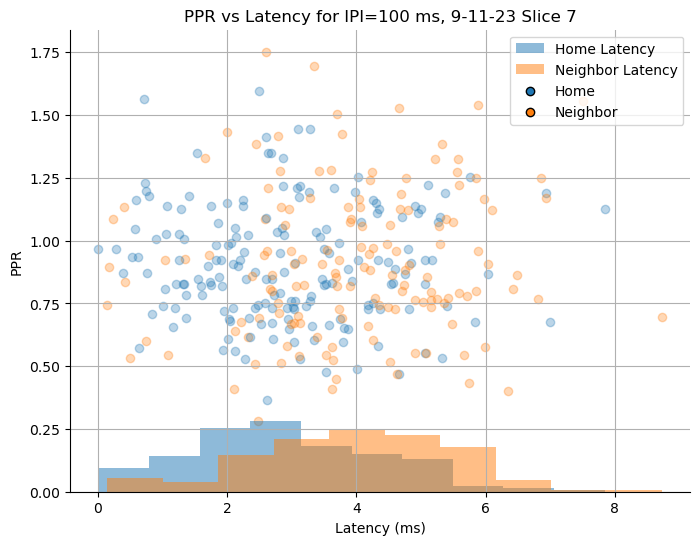

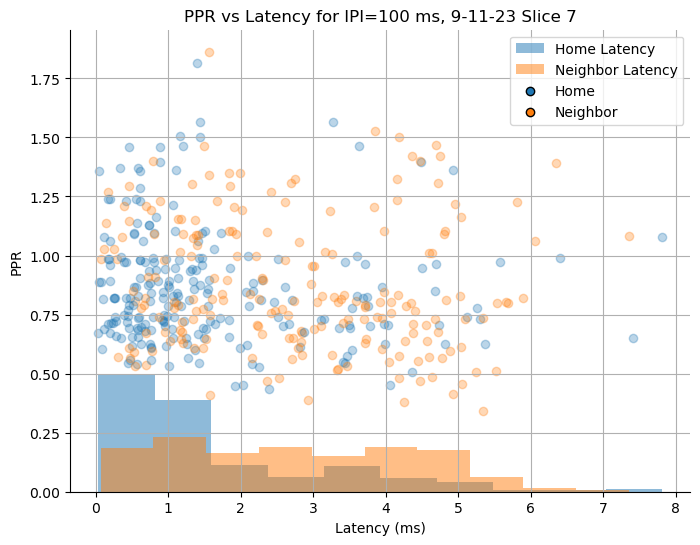

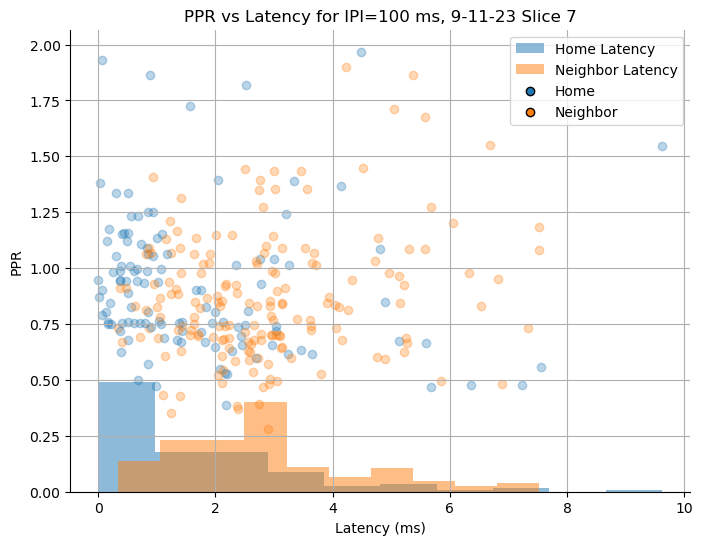

In [24]:
# do PPR and latency correlate? scatter of PPR vs latency for pulse 1, for IPI = 100 ms
# for 9-11-23 slices 5 and 7, color by neighbor vs home, label stim layer for each point
ipi = 100
for slic in [7]:
    for stim_loc in ['L2/3', 'L4', 'L5']:
        subset_df = ppr_df[(ppr_df['IPI'] == ipi) & (ppr_df['Date'] == '23-9-11') & (ppr_df['Slice'].isin([slic])) & (ppr_df['Stim_Layer'] == stim_loc)]
        # only latency > 0
        subset_df = subset_df[(subset_df['latency'] > 0) & (subset_df['latency'] < 10)]
        # only PPR between 0 and 2
        subset_df = subset_df[(subset_df['PPR'] > 0) & (subset_df['PPR'] < 2)]
        # filter low amp (outside of 80 percentile of the amp array)
        amp_array = subset_df['amp_array'].values[0]
        amp_array = read_array_file(amp_array)
        amp_threshold = np.percentile(amp_array, 70)
        subset_df = subset_df[subset_df['amp'] >= amp_threshold]
        plt.figure(figsize=(8, 6))
        colors = {'Home': 'tab:blue', 'Neighbor': 'tab:orange'}
        for index, row in subset_df.iterrows():
            plt.scatter(row['latency'], row['PPR'], alpha=0.3, color=colors[row['Neighbor_Type']])
            #plt.text(row['latency'], row['PPR'], row['Stim_Layer'] + "->" + row['ROI_Loc'], fontsize=8, ha='right')

        # along the x-axis, plot histgram of latency values, separated by neighbor vs home; normalize histogram to be between 0 and 1; make bars semi-transparent
        home_subset = subset_df[subset_df['Neighbor_Type'] == 'Home']
        neighbor_subset = subset_df[subset_df['Neighbor_Type'] == 'Neighbor']
        plt.hist(home_subset['latency'], bins=10, alpha=0.5, color='tab:blue', label='Home Latency', density=True)
        plt.hist(neighbor_subset['latency'], bins=10, alpha=0.5, color='tab:orange', label='Neighbor Latency', density=True)
        plt.xlabel('Latency (ms)')
        plt.ylabel('PPR')
        plt.title(f'PPR vs Latency for IPI={ipi} ms, 9-11-23 Slice {slic}')
        plt.grid(True)
        # remove top and right spines
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        # legend: orange is neighbor, blue is home
        plt.scatter([], [], color='tab:blue', edgecolors='k', label='Home')
        plt.scatter([], [], color='tab:orange', edgecolors='k', label='Neighbor')
        plt.legend()
        plt.savefig(output_fig_dir + f'ppr_vs_latency_single_px_scatter_ipi_stim_{stim_loc.replace("/", "")}_ipi{ipi}ms_9-11-23_slice_{slic}.png')
        plt.show()

Index(['ROI', 'amp', 'latency', 'stim_time', 'halfwidth', 'X_Center',
       'Y_Center', 'ROI_Set', 'Date', 'Slice', 'Location', 'Recording',
       'trace', 'amp_array', 'latency_array', 'Section', 'IPI', 'Stim_Layer',
       'Sex', 'Age', 'Pulse_Number', 'ROI_Label', 'ROI_Loc', 'PPR', 'PPL',
       'PPHW', 'Neighbor_Type'],
      dtype='object')
Plotting ROI 5 at (25, 75)
Plotting ROI 10 at (29, 66)
Plotting ROI 15 at (32, 72)
Plotting ROI 20 at (35, 72)
Plotting ROI 25 at (34, 68)
Plotting ROI 30 at (35, 73)
Plotting ROI 35 at (36, 76)
Plotting ROI 40 at (29, 79)
Plotting ROI 45 at (26, 75)
Plotting ROI 50 at (24, 68)
Plotting ROI 55 at (22, 68)
Plotting ROI 60 at (37, 78)
Plotting ROI 65 at (39, 79)
Plotting ROI 70 at (36, 79)
Plotting ROI 75 at (39, 78)
Plotting ROI 80 at (29, 71)
Plotting ROI 85 at (27, 78)
Plotting ROI 90 at (33, 72)
Plotting ROI 95 at (21, 75)
Plotting ROI 100 at (36, 72)


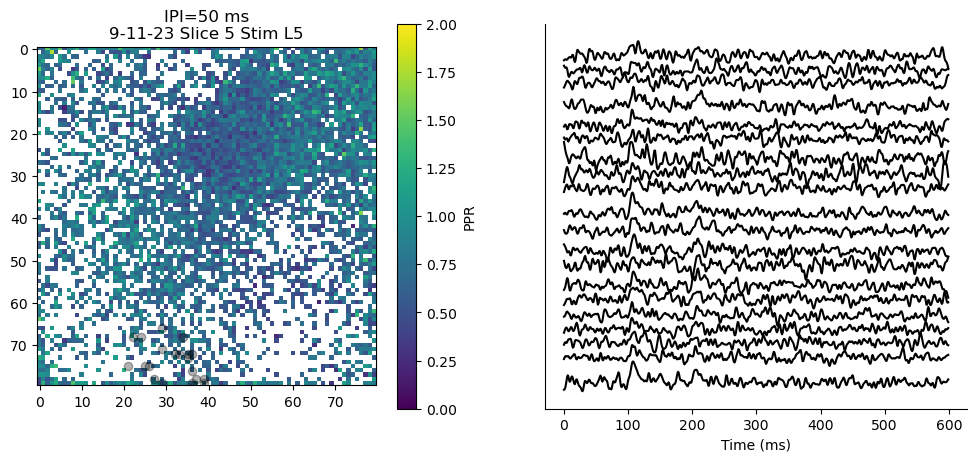

Plotting ROI 5 at (11, 71)
Plotting ROI 10 at (16, 65)
Plotting ROI 15 at (10, 73)
Plotting ROI 20 at (9, 75)
Plotting ROI 25 at (16, 69)
Plotting ROI 30 at (7, 67)
Plotting ROI 35 at (13, 68)
Plotting ROI 40 at (6, 64)
Plotting ROI 45 at (11, 69)
Plotting ROI 50 at (16, 63)
Plotting ROI 55 at (8, 67)
Plotting ROI 60 at (10, 67)
Plotting ROI 65 at (7, 61)
Plotting ROI 70 at (10, 65)
Plotting ROI 75 at (10, 72)
Plotting ROI 80 at (14, 72)
Plotting ROI 85 at (8, 74)
Plotting ROI 90 at (14, 73)
Plotting ROI 95 at (13, 73)
Plotting ROI 100 at (6, 65)


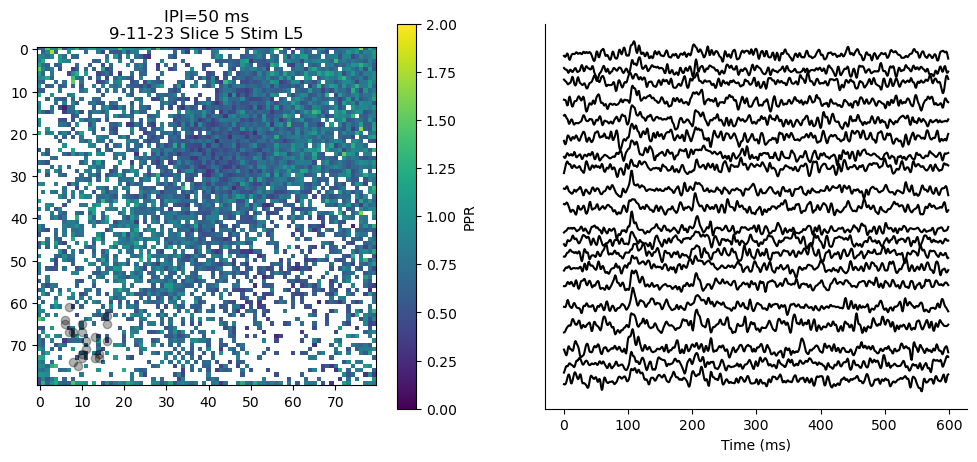

Plotting ROI 5 at (51, 77)
Plotting ROI 10 at (46, 77)
Plotting ROI 15 at (48, 76)
Plotting ROI 20 at (44, 75)
Plotting ROI 25 at (53, 77)
Plotting ROI 30 at (56, 75)
Plotting ROI 35 at (55, 76)
Plotting ROI 40 at (44, 79)
Plotting ROI 45 at (55, 78)
Plotting ROI 50 at (47, 75)
Plotting ROI 55 at (50, 78)
Plotting ROI 60 at (50, 79)
Plotting ROI 65 at (46, 78)
Plotting ROI 70 at (46, 79)
Plotting ROI 75 at (45, 78)


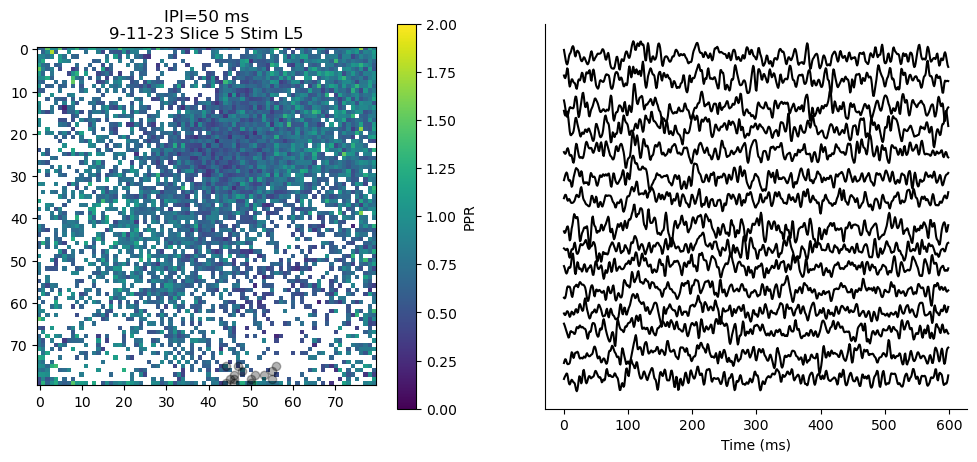

Plotting ROI 5 at (37, 50)
Plotting ROI 10 at (44, 47)
Plotting ROI 15 at (41, 52)
Plotting ROI 20 at (47, 56)
Plotting ROI 25 at (35, 53)
Plotting ROI 30 at (38, 55)
Plotting ROI 35 at (44, 53)
Plotting ROI 40 at (46, 58)
Plotting ROI 45 at (40, 64)
Plotting ROI 50 at (41, 60)
Plotting ROI 55 at (33, 48)
Plotting ROI 60 at (42, 48)
Plotting ROI 65 at (45, 55)
Plotting ROI 70 at (43, 63)
Plotting ROI 75 at (38, 48)
Plotting ROI 80 at (31, 62)
Plotting ROI 85 at (48, 51)
Plotting ROI 90 at (31, 57)
Plotting ROI 95 at (41, 62)
Plotting ROI 100 at (34, 56)


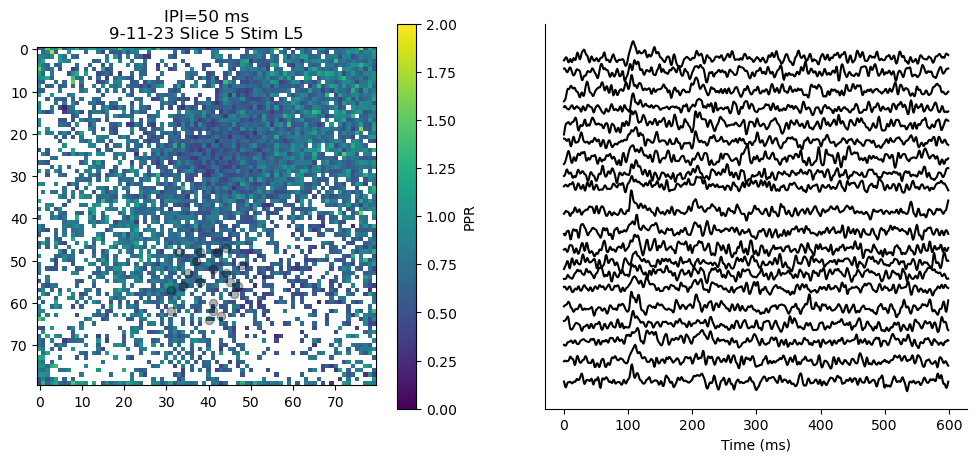

Plotting ROI 5 at (14, 53)
Plotting ROI 10 at (18, 52)
Plotting ROI 15 at (13, 49)
Plotting ROI 20 at (13, 55)
Plotting ROI 25 at (21, 53)
Plotting ROI 30 at (22, 44)
Plotting ROI 35 at (15, 47)
Plotting ROI 40 at (17, 43)
Plotting ROI 45 at (20, 45)
Plotting ROI 50 at (25, 48)
Plotting ROI 55 at (18, 44)
Plotting ROI 60 at (24, 55)
Plotting ROI 65 at (10, 53)
Plotting ROI 70 at (12, 58)
Plotting ROI 75 at (20, 52)
Plotting ROI 80 at (13, 57)
Plotting ROI 85 at (14, 43)
Plotting ROI 90 at (16, 46)
Plotting ROI 95 at (18, 49)
Plotting ROI 100 at (22, 52)


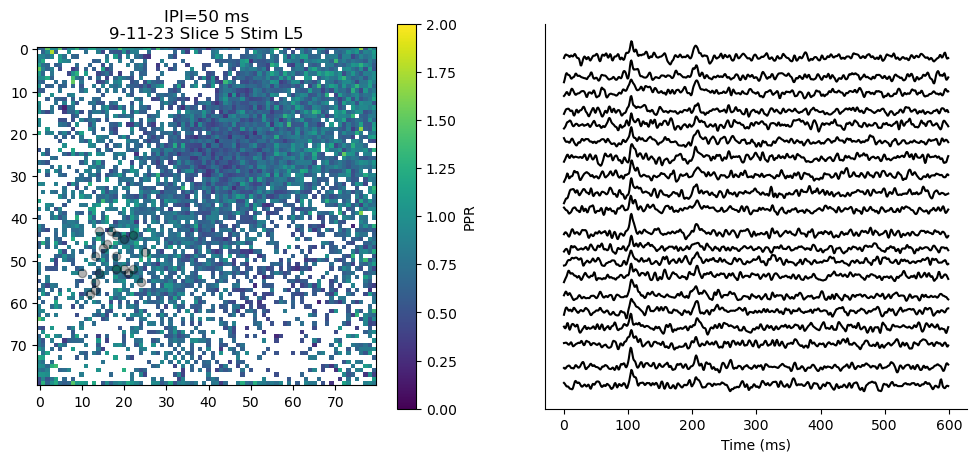

Plotting ROI 5 at (65, 58)
Plotting ROI 10 at (59, 67)
Plotting ROI 15 at (57, 66)
Plotting ROI 20 at (55, 67)
Plotting ROI 25 at (64, 67)
Plotting ROI 30 at (65, 56)
Plotting ROI 35 at (62, 59)
Plotting ROI 40 at (58, 58)
Plotting ROI 45 at (64, 53)
Plotting ROI 50 at (61, 59)
Plotting ROI 55 at (53, 61)
Plotting ROI 60 at (64, 56)
Plotting ROI 65 at (56, 57)
Plotting ROI 70 at (64, 57)
Plotting ROI 75 at (60, 64)
Plotting ROI 80 at (63, 61)
Plotting ROI 85 at (57, 61)
Plotting ROI 90 at (62, 57)
Plotting ROI 95 at (54, 61)
Plotting ROI 100 at (54, 54)


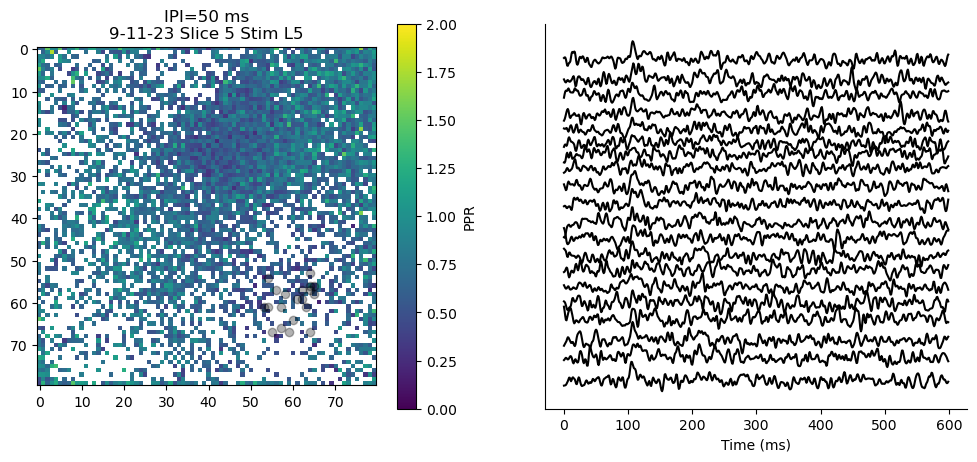

Plotting ROI 5 at (42, 34)
Plotting ROI 10 at (40, 29)
Plotting ROI 15 at (39, 36)
Plotting ROI 20 at (38, 34)
Plotting ROI 25 at (50, 22)
Plotting ROI 30 at (43, 22)
Plotting ROI 35 at (50, 25)
Plotting ROI 40 at (49, 30)
Plotting ROI 45 at (45, 30)
Plotting ROI 50 at (46, 31)
Plotting ROI 55 at (40, 18)
Plotting ROI 60 at (54, 29)
Plotting ROI 65 at (45, 35)
Plotting ROI 70 at (43, 36)
Plotting ROI 75 at (54, 23)
Plotting ROI 80 at (43, 27)
Plotting ROI 85 at (38, 35)
Plotting ROI 90 at (40, 34)
Plotting ROI 95 at (39, 25)
Plotting ROI 100 at (54, 21)


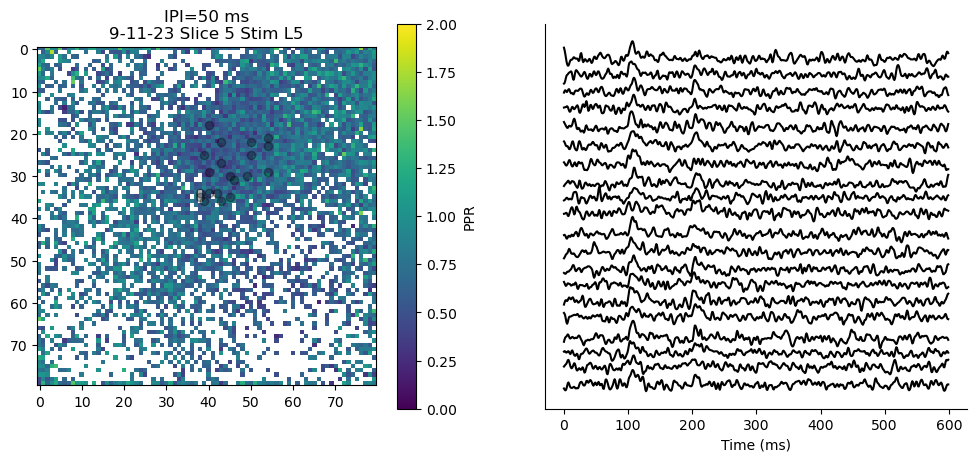

Plotting ROI 5 at (25, 20)
Plotting ROI 10 at (15, 26)
Plotting ROI 15 at (20, 17)
Plotting ROI 20 at (17, 24)
Plotting ROI 25 at (16, 31)
Plotting ROI 30 at (20, 24)
Plotting ROI 35 at (27, 27)
Plotting ROI 40 at (29, 31)
Plotting ROI 45 at (25, 31)
Plotting ROI 50 at (17, 16)
Plotting ROI 55 at (19, 32)
Plotting ROI 60 at (31, 14)
Plotting ROI 65 at (15, 14)
Plotting ROI 70 at (19, 23)
Plotting ROI 75 at (27, 26)
Plotting ROI 80 at (16, 18)
Plotting ROI 85 at (28, 25)
Plotting ROI 90 at (20, 23)
Plotting ROI 95 at (16, 21)
Plotting ROI 100 at (30, 19)


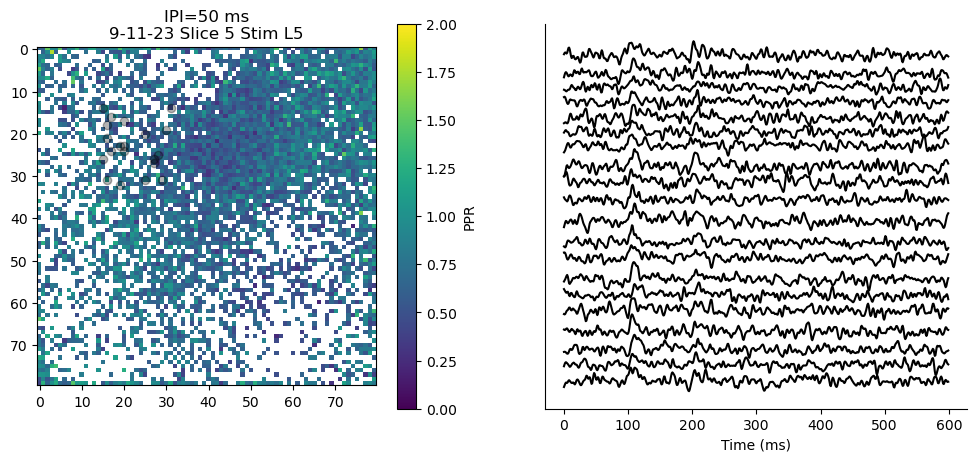

Plotting ROI 5 at (73, 30)
Plotting ROI 10 at (70, 40)
Plotting ROI 15 at (64, 41)
Plotting ROI 20 at (59, 39)
Plotting ROI 25 at (60, 34)
Plotting ROI 30 at (71, 35)
Plotting ROI 35 at (65, 40)
Plotting ROI 40 at (67, 43)
Plotting ROI 45 at (62, 24)
Plotting ROI 50 at (66, 24)
Plotting ROI 55 at (62, 42)
Plotting ROI 60 at (70, 43)
Plotting ROI 65 at (65, 29)
Plotting ROI 70 at (65, 42)
Plotting ROI 75 at (60, 42)
Plotting ROI 80 at (64, 29)
Plotting ROI 85 at (71, 40)
Plotting ROI 90 at (70, 39)
Plotting ROI 95 at (59, 32)
Plotting ROI 100 at (69, 39)


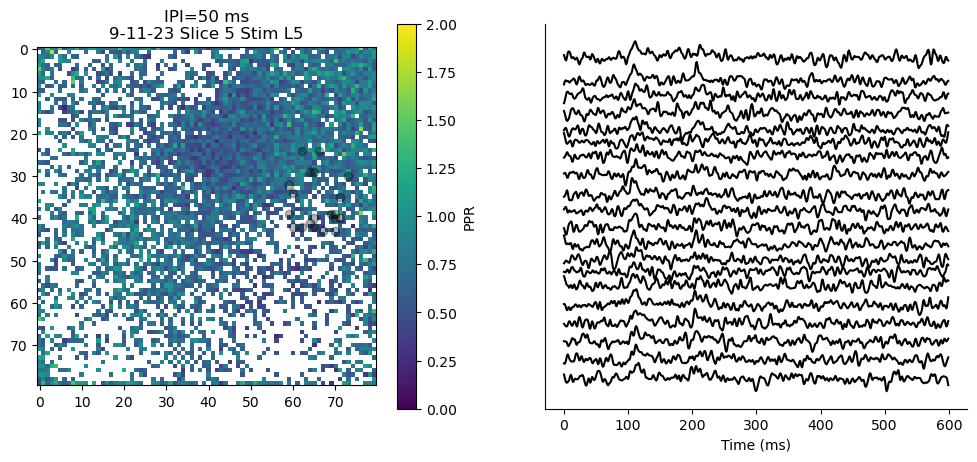

In [44]:
# make a PPR map for example by dividing amp_array of pulse 2 by amp_array of pulse 1 for each pixel, then plot as a heatmap
# ignore pixels with amp lesser than 80 percentile of max amp for pulse 1
ipi = 50
print(ppr_df.columns)
for slic in [5]:
    for stim_loc in ['L5']:
        subset_df = ppr_df[(ppr_df['IPI'] == ipi) & (ppr_df['Date'] == '23-9-11') & (ppr_df['Slice'].isin([slic])) & (ppr_df['Stim_Layer'] == stim_loc)]
        pulse_1_subset = subset_df[subset_df['Pulse_Number'] == 1]
        pulse_2_subset = subset_df[subset_df['Pulse_Number'] == 2]

        for loc in pulse_1_subset['ROI_Loc'].unique():
            pulse_1_loc_subset = pulse_1_subset[pulse_1_subset['ROI_Loc'] == loc]
            pulse_2_loc_subset = pulse_2_subset[pulse_2_subset['ROI_Loc'] == loc]
            for rec in pulse_1_loc_subset['Recording'].unique():
                pulse_1_rec_subset = pulse_1_loc_subset[pulse_1_loc_subset['Recording'] == rec]
                pulse_2_rec_subset = pulse_2_loc_subset[pulse_2_loc_subset['Recording'] == rec]
                plt.figure(figsize=(12, 5))

                # left subplot 
                plt.subplot(1, 2, 1)
                amp_arr1 = pulse_1_rec_subset['amp_array'].values[0]
                amp_arr2 = pulse_2_rec_subset['amp_array'].values[0]

                amp_arr1 = read_array_file(amp_arr1)
                amp_arr2 = read_array_file(amp_arr2)
                ppr_map = amp_arr2 / amp_arr1
                # filter low amp pixels based on pulse 1
                amp_threshold = np.percentile(amp_arr1, 40)
                ppr_map[amp_arr1 < amp_threshold] = np.nan
                plt.imshow(ppr_map, cmap='viridis', vmin=0, vmax=2)
                plt.colorbar(label='PPR')
                plt.title(f'IPI={ipi} ms\n9-11-23 Slice {slic} Stim {stim_loc}')
                #plt.savefig(output_fig_dir + f'ppr_map_ipi_stim_{stim_loc.replace("/", "")}_ipi{ipi}ms_9-11-23_slice_{slic}_loc_{loc}_rec_{rec}.png')
                roi_colors = ['red', 'blue', 'green', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'brown', 'pink']

                # mark the ROI centers on the PPR map
                i_roi = -1
                for index, row in pulse_1_rec_subset.iterrows():
                    roi = row['ROI']
                    if roi % 5 != 0:
                        continue
                    i_roi += 1
                    x_center = row['X_Center']
                    y_center = row['Y_Center']
                    print(f"Plotting ROI {roi} at ({x_center}, {y_center})")
                    roi = row['ROI']
                    plt.scatter(x_center, y_center, color='k', edgecolors='k', alpha=0.3)

                plt.subplot(1, 2, 2)
                # choose some example ROIs to plot the trace for
                overhead = 0
                i_roi = -1
                for roi in pulse_1_rec_subset['ROI'].unique():
                    if roi % 5 != 0:
                        continue
                    i_roi += 1
                    roi_pulse_1_subset = pulse_1_rec_subset[pulse_1_rec_subset['ROI'] == roi]
                    trace1 = read_dat_trace_file(roi_pulse_1_subset['trace'].values[0])['ROI' + str(roi)].values

                    plt.plot(trace1 + overhead, label='ROI ' + str(roi), color='k')
                    overhead += trace1.max() * 1.2  # add some space between traces
                plt.xlabel('Time (ms)')
                # spines off
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                # y ticks off
                plt.yticks([])
                #plt.savefig(output_fig_dir + f'traces_roi_{roi}_loc_{loc}_rec_{rec}.png')

                plt.show()

## 